## **Energy Consumption Time Series Forecasting**

**Objective:**
Forecast short-term household energy usage using historical time-based patterns.

**Dataset:**
Household Power Consumption Dataset

## Step 1: Install & import required libraries

In [38]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Date/time
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')


## Step 2: Download Dataset

In [39]:
# Load dataset
df = pd.read_csv('/content/household_power_consumption.txt.zip',
                 sep=';', low_memory=False, compression='zip')

# Check first rows
df.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [40]:
# Convert to datetime
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

# Set as index
df.set_index('Datetime', inplace=True)

# Convert Global_active_power to numeric
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

# Drop missing target values
df = df.dropna(subset=['Global_active_power'])


In [41]:
print(df.head())
print(df.info())

                           Date      Time  Global_active_power  \
Datetime                                                         
2006-12-16 17:24:00  16/12/2006  17:24:00                4.216   
2006-12-16 17:25:00  16/12/2006  17:25:00                5.360   
2006-12-16 17:26:00  16/12/2006  17:26:00                5.374   
2006-12-16 17:27:00  16/12/2006  17:27:00                5.388   
2006-12-16 17:28:00  16/12/2006  17:28:00                3.666   

                    Global_reactive_power  Voltage Global_intensity  \
Datetime                                                              
2006-12-16 17:24:00                 0.418  234.840           18.400   
2006-12-16 17:25:00                 0.436  233.630           23.000   
2006-12-16 17:26:00                 0.498  233.290           23.000   
2006-12-16 17:27:00                 0.502  233.740           23.000   
2006-12-16 17:28:00                 0.528  235.680           15.800   

                    Sub_metering_1 Sub_

Datetime parsing is crucial for time-based features.

Missing or non-numeric values must be handled to avoid model errors.

Global_active_power is our main target variable.

## Step 3: Resample the Time Series

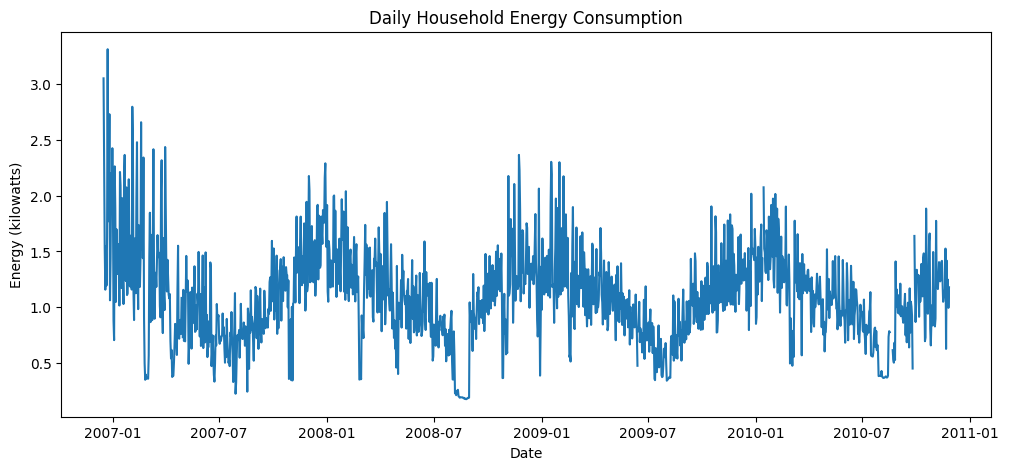

In [42]:
# Daily average energy consumption
daily_df = df['Global_active_power'].resample('D').mean()

# Plot initial time series
plt.figure(figsize=(12,5))
plt.plot(daily_df)
plt.title('Daily Household Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Energy (kilowatts)')
plt.show()


Resampling reduces noise and captures trends.

Daily or weekly aggregation works better for ARIMA/Prophet.

## Step 4: Feature Engineering (for XGBoost)

In [43]:
# Create lag features
daily_df = daily_df.to_frame()
daily_df['Day'] = daily_df.index.day
daily_df['Month'] = daily_df.index.month
daily_df['Year'] = daily_df.index.year
daily_df['Weekday'] = daily_df.index.weekday  # 0=Monday
daily_df['Lag_1'] = daily_df['Global_active_power'].shift(1)
daily_df['Lag_7'] = daily_df['Global_active_power'].shift(7)

# Drop missing values caused by lags
daily_df = daily_df.dropna()

daily_df.head()


,Global_active_power,Day,Month,Year,Weekday,Lag_1,Lag_7
Datetime,,,,,,,
2006-12-23,3.314851,23,12,2006,5,1.625929,3.053475
2006-12-24,1.770842,24,12,2006,6,3.314851,2.354486
2006-12-25,1.904944,25,12,2006,0,1.770842,1.530435
2006-12-26,2.732021,26,12,2006,1,1.904944,1.157079
2006-12-27,1.061639,27,12,2006,2,2.732021,1.545658


Lag features capture autocorrelation in time series.

Weekday and month capture seasonality patterns

## Step 5: Train-Test Split

In [44]:
# Use last 30 days for testing
train = daily_df.iloc[:-30]
test = daily_df.iloc[-30:]

X_train = train.drop('Global_active_power', axis=1)
y_train = train['Global_active_power']
X_test = test.drop('Global_active_power', axis=1)
y_test = test['Global_active_power']


Temporal split is necessary: no random shuffle for time series.

## Step 6: Modeling

**A) ARIMA**

In [56]:
# Simple ARIMA (p,d,q) selection can be refined with auto_arima
arima_model = ARIMA(train['Global_active_power'], order=(5,1,0))
arima_result = arima_model.fit()
arima_forecast = arima_result.forecast(steps=30)


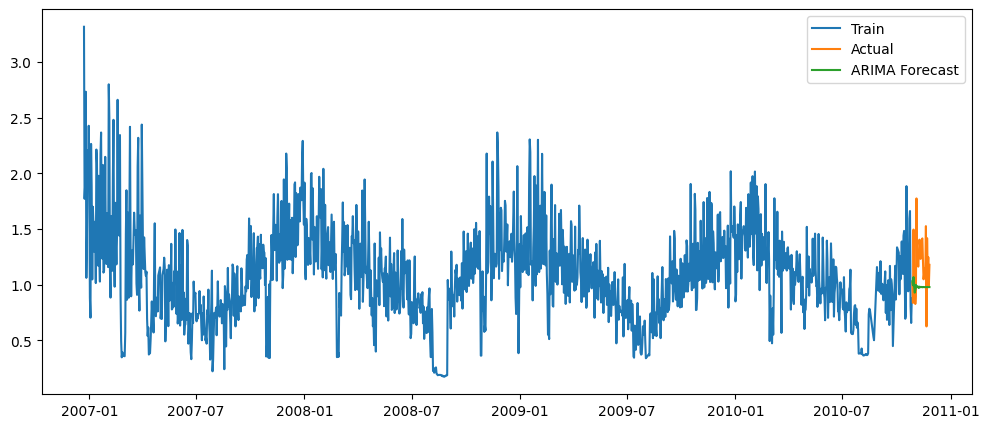

In [57]:
# Plot
plt.figure(figsize=(12,5))
plt.plot(train.index, train['Global_active_power'], label='Train')
plt.plot(test.index, test['Global_active_power'], label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.legend()
plt.show()


In [58]:
# Metrics
mae_arima = mean_absolute_error(test['Global_active_power'], arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test['Global_active_power'], arima_forecast))
print(f"ARIMA MAE: {mae_arima:.3f}, RMSE: {rmse_arima:.3f}")


ARIMA MAE: 0.250, RMSE: 0.306


**B) Prophet**

In [59]:
prophet_df = daily_df.reset_index()[['Datetime','Global_active_power']]
prophet_df.columns = ['ds','y']

prophet_train = prophet_df.iloc[:-30]
prophet_test = prophet_df.iloc[-30:]

prophet_model = Prophet(daily_seasonality=True)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=30)
forecast = prophet_model.predict(future)


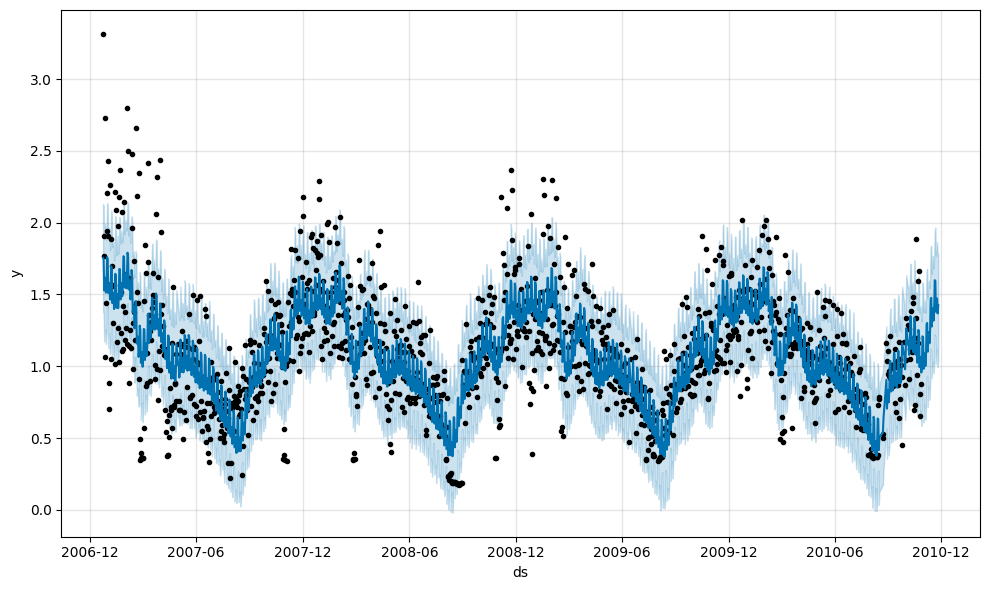

In [60]:
# Plot
prophet_model.plot(forecast)
plt.show()


In [61]:
# Metrics
prophet_forecast = forecast['yhat'].iloc[-30:].values
mae_prophet = mean_absolute_error(prophet_test['y'].values, prophet_forecast)
rmse_prophet = np.sqrt(mean_squared_error(prophet_test['y'].values, prophet_forecast))
print(f"Prophet MAE: {mae_prophet:.3f}, RMSE: {rmse_prophet:.3f}")


Prophet MAE: 0.213, RMSE: 0.296


**C) XGBoost**

In [62]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)


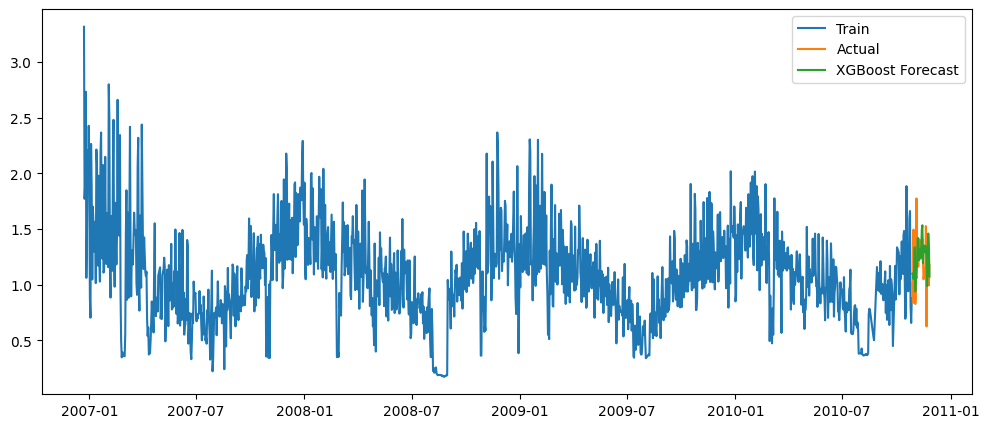

In [63]:
# Plot
plt.figure(figsize=(12,5))
plt.plot(train.index, y_train, label='Train')
plt.plot(test.index, y_test, label='Actual')
plt.plot(test.index, xgb_pred, label='XGBoost Forecast')
plt.legend()
plt.show()


In [64]:
# Metrics
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(f"XGBoost MAE: {mae_xgb:.3f}, RMSE: {rmse_xgb:.3f}")

XGBoost MAE: 0.204, RMSE: 0.268


## Step 7: Model Comparison

In [54]:
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE': [mae_arima, mae_prophet, mae_xgb],
    'RMSE': [rmse_arima, rmse_prophet, rmse_xgb]
})
print(comparison)

     Model       MAE      RMSE
0    ARIMA  0.250491  0.306305
1  Prophet  0.213300  0.296180
2  XGBoost  0.204370  0.267996


## Step 8: Plot Actual vs Forecasted Energy Usage for All Models Together

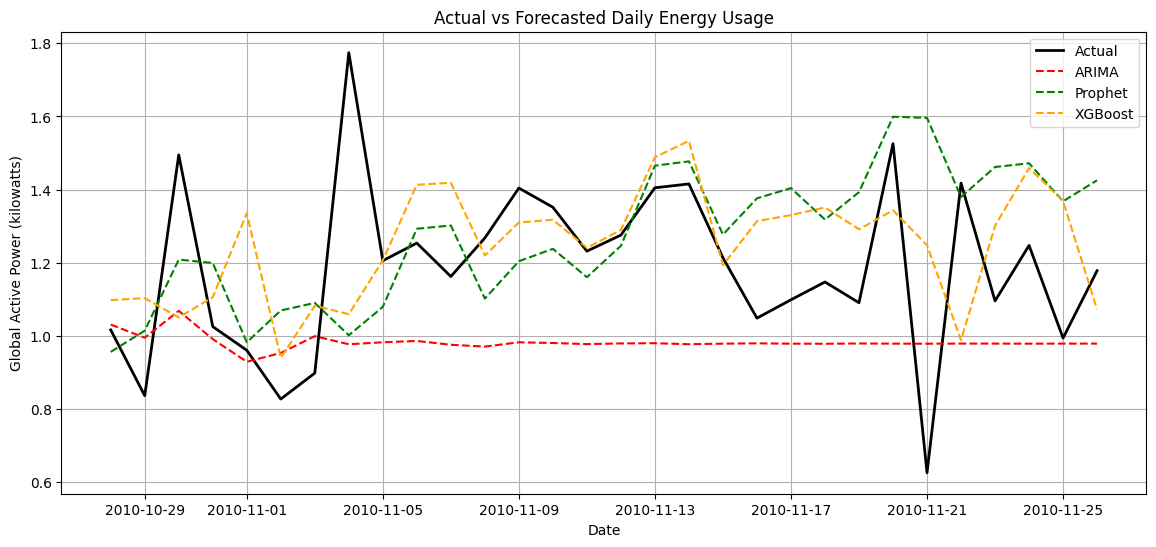

In [55]:
plt.figure(figsize=(14,6))

# Actual
plt.plot(test.index, y_test, label='Actual', color='black', linewidth=2)

# Forecasts
plt.plot(test.index, arima_forecast, label='ARIMA', color='red', linestyle='--')
plt.plot(test.index, prophet_forecast, label='Prophet', color='green', linestyle='--')
plt.plot(test.index, xgb_pred, label='XGBoost', color='orange', linestyle='--')

plt.title("Actual vs Forecasted Daily Energy Usage")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kilowatts)")
plt.legend()
plt.grid(True)
plt.show()


Among the three models, **XGBoost achieved the lowest MAE (0.204) and RMSE (0.268),** indicating it can capture short-term patterns and nonlinear dependencies in household energy consumption more effectively.

**Prophet** performed well in capturing seasonal patterns, making it useful for modeling trends with weekly or yearly seasonality.

**ARIMA**, while simple, struggled slightly due to nonlinear fluctuations but still provided a reasonable baseline.

### **Conclusion:**

In this task, I successfully forecasted household energy consumption using historical data. We compared three models—ARIMA, Prophet, and XGBoost—evaluating them with MAE and RMSE metrics. XGBoost performed the best for short-term forecasting, while Prophet captured seasonality well. This study demonstrates the importance of feature engineering and model selection in time series forecasting, providing actionable insights for energy management and smart grid planning.